# Analysis of NO₂ Air Pollution in Tower Hamlets (2023-2024)

* Author: David Rodriguez
#
#
This project analyses nitrogen dioxide (NO₂) air pollution data collected from diffusion tube monitoring sites in the London Borough of Tower Hamlets during 2023 and 2024. The aim is to explore differences in average NO₂ concentrations between years, monitoring site types, and months, while identifying seasonal trends and changes in air quality. The analysis was carried out using Python, with the Pandas library for data manipulation and Matplotlib for data visualisation.



#1. Import libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

This cell imports the necessary libraries, `pandas` for data manipulation and `matplotlib.pyplot` for plotting.

#2. Loading both datasets

In [24]:
df_2024 = pd.read_excel('/content/Diffusion Tube Data (2024).xlsx',
                        sheet_name='LB Tower Hamlets'
)

df_2023 = pd.read_excel('/content/DT_data_2023 (4).xlsx', sheet_name = 'LB Tower Hamlets')


The datasets for 2023 and 2024 are loaded into pandas DataFrames from Excel files.

#3. Inspection of data sets

In [25]:
display(df_2024.head())

df_2024.info()

df_2024.isna().sum()

display(df_2023.head())
display(df_2023.info())
display(df_2023.isna().sum())

#Check first if there is a difference between number
#of sites of 2023 and 2024 for reliable comparison

site_type_counts_2023 = df_2023['Site Type'].value_counts()

print(site_type_counts_2023)

df_2023.columns

#Notice the lower number of sites possible limitation

,London Borough,Site ID,Site Name,Site Type,X (m),Y (m),Valid data capture for monitoring period (%),Valid data capture (%),Jan,Feb,...,May,Jun,Jul,Aug,Sept,Oct,Nov,Dec,Annual mean - raw data,Annual mean - annualised and bias adjusted
0,London Borough of Tower Hamlets,"42, 43",Victoria Park (Co-location site),Urban Background,536494,184170,100,100,19.6,18.35,...,13.25,9.6,10.95,12.9,10.45,14.6,22.5,10.9,14.15,11.03
1,London Borough of Tower Hamlets,55,TH Cemetery Park,Roadside,536732,182361,100,100,19.9,20.20,...,13.40,12.7,11.50,12.9,16.50,16.6,21.6,8.1,15.19,11.85
2,London Borough of Tower Hamlets,66,Millwall Park,Urban Background,538258,178689,100,100,25.5,22.70,...,16.00,14.1,14.00,15.7,16.90,21.5,26.6,14.8,18.50,14.43
3,London Borough of Tower Hamlets,17,Finnis St/Three Colts Lane,Kerbside,534783,182385,100,100,25.0,25.10,...,18.90,15.5,16.70,15.9,19.40,24.2,27.0,12.5,19.31,15.06
4,London Borough of Tower Hamlets,63,Millwall Park,Urban Background,538246,178689,75,75,24.4,22.80,...,NaN,NaN,17.10,16.8,NaN,20.7,25.7,15.6,19.54,15.24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   London Borough                                91 non-null     object 
 1   Site ID                                       91 non-null     object 
 2   Site Name                                     91 non-null     object 
 3   Site Type                                     91 non-null     object 
 4   X (m)                                         91 non-null     int64  
 5   Y (m)                                         91 non-null     int64  
 6   Valid data capture for monitoring period (%)  91 non-null     int64  
 7   Valid data capture (%)                        91 non-null     int64  
 8   Jan                                           84 non-null     float64
 9   Feb                                           84 non-null     float

,Site ID,Site Name,X (m),Y (m),Site Type,Valid data capture for monitoring period %(a),Valid data capture 2023 %(b),Jan,Feb,Mar,...,May,June,Jul,Aug,Sept,Oct,Nov,Dec,Annual mean – raw data,Annual mean – annualised and bias adjusted
0,32,Globe Rd/Mile End Rd,535634,182148,Kerbside,100,100,48.3,46.4,48.5,...,32.8,35.6,26.6,30.9,39.1,40.5,43.5,31.2,38.04,29.29
1,31,Whitechapel Market,534516,181744,Roadside,100,100,48.5,64.1,44.2,...,45.4,41.7,43.8,45,55.6,55.3,54.6,43,49.27,37.94
2,30,Fieldgate Street,534239,181565,Kerbside,92,92,37.2,43.2,26.4,...,29.1,32.4,24.1,27.4,50.3,-,32.4,33.7,34.10,26.26
3,29,Grove Rd/Old Ford Rd,535930,183385,Kerbside,100,100,39.8,42.6,26.2,...,25.9,29.9,25.5,29.9,38.7,38.9,38.7,33.1,33.87,26.08
4,28,Bonner Road,535356,183223,Kerbside,92,92,53,52.8,38.3,...,37.5,36,37.9,37.9,-,34,37.4,37.9,40.79,31.41


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Site ID                                         32 non-null     int64  
 1   Site Name                                       32 non-null     object 
 2   X (m)                                           32 non-null     int64  
 3   Y (m)                                           32 non-null     int64  
 4   Site Type                                       32 non-null     object 
 5   Valid data capture for monitoring period %(a)   32 non-null     int64  
 6   Valid data capture 2023 %(b)                    32 non-null     int64  
 7   Jan                                             32 non-null     object 
 8   Feb                                             32 non-null     object 
 9   Mar                                          

None

,0
Site ID,0
Site Name,0
X (m),0
Y (m),0
Site Type,0
Valid data capture for monitoring period %(a),0
Valid data capture 2023 %(b),0
Jan,0
Feb,0
Mar,0


Site Type
Kerbside    28
Roadside     4
Name: count, dtype: int64


Index(['Site ID ', 'Site Name', 'X (m)', 'Y (m)', 'Site Type',
       'Valid data capture for monitoring period %(a) ',
       'Valid data capture 2023 %(b) ', 'Jan ', 'Feb', 'Mar ', 'Apr ', 'May ',
       'June ', 'Jul ', 'Aug ', 'Sept ', 'Oct ', 'Nov ', 'Dec ',
       'Annual mean – raw data ',
       'Annual mean – annualised and bias adjusted '],
      dtype='object')

These commands display the head, information, and missing values for both 2024 and 2023 datasets, along with site type counts for 2023, to get a preliminary understanding of the data.

#4. Data Analysis

##4.1 Average annual NO₂ by Site Type

Site Type
Kerbside            73
Roadside            14
Urban Background     4
Name: count, dtype: int64


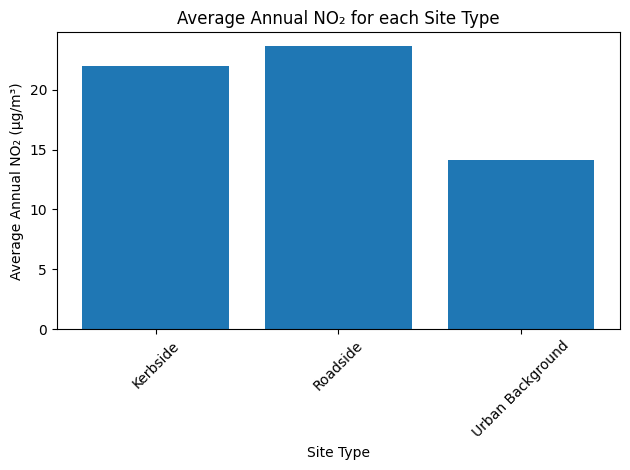

In [26]:
site_type_counts_2024 = df_2024['Site Type'].value_counts()

print (site_type_counts_2024)

#Realise that the counts are imbalanced.

avg_annual_no2_by_site_2024 = df_2024.groupby('Site Type')['Annual mean - annualised and bias adjusted'].mean()

plt.bar(avg_annual_no2_by_site_2024.index, avg_annual_no2_by_site_2024.values)

plt.xlabel('Site Type')
plt.ylabel('Average Annual NO₂ (µg/m³)')
plt.title('Average Annual NO₂ for each Site Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This cell calculates and visualizes the average annual NO₂ concentrations by site type for 2024 to understand the distribution across different monitoring environments.

##4.2 Monthly NO₂ trend (2024)

Jan     31.890476
Feb     32.439881
Mar     30.384337
Apr     24.457059
May     27.377059
Jun     24.246341
Jul     25.257865
Aug     25.027586
Sept    27.182386
Oct     30.668675
Nov     35.952564
Dec     23.261039
dtype: float64


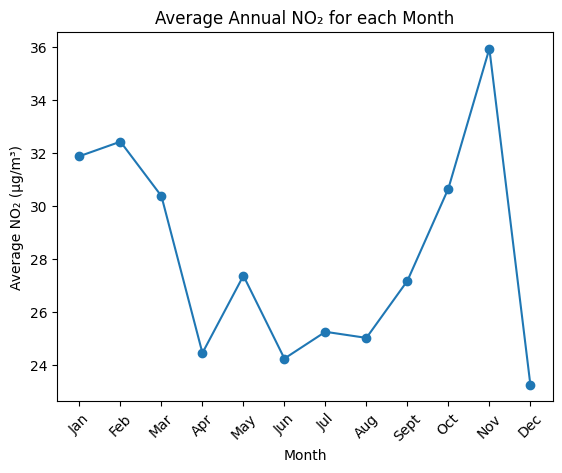

In [27]:
avg_monthly_no2_2024 = df_2024[['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']].mean()

print(avg_monthly_no2_2024)

plt.plot(avg_monthly_no2_2024.index, avg_monthly_no2_2024.values , marker='o')
plt.xlabel('Month')
plt.ylabel('Average NO₂ (µg/m³)')
plt.title('Average Annual NO₂ for each Month')
plt.xticks(rotation=45)
plt.show()

This section calculates and plots the overall average monthly NO₂ concentrations for 2024 to identify any general seasonal trends.

## 4.3 Monthly trend by Site Type

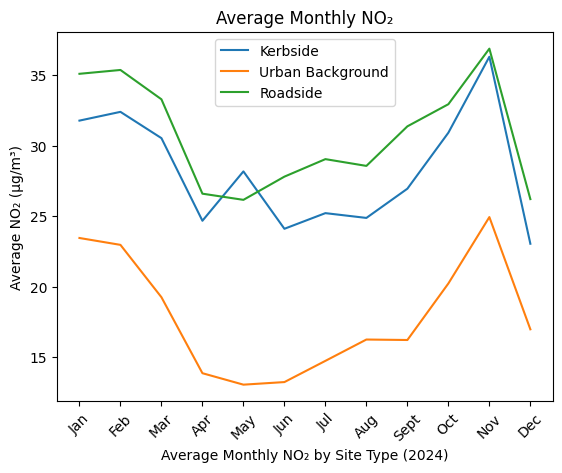

In [28]:
avg_monthly_no2_by_site_2024 = df_2024.groupby('Site Type')[['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']].mean()


plt.plot(avg_monthly_no2_by_site_2024.columns, avg_monthly_no2_by_site_2024.loc['Kerbside'], label = 'Kerbside')
plt.plot(avg_monthly_no2_by_site_2024.columns, avg_monthly_no2_by_site_2024.loc['Urban Background'], label = 'Urban Background')
plt.plot(avg_monthly_no2_by_site_2024.columns, avg_monthly_no2_by_site_2024.loc['Roadside'], label = 'Roadside')
plt.legend()
plt.xlabel('Average Monthly NO₂ by Site Type (2024)')
plt.ylabel('Average NO₂ (µg/m³)')
plt.title('Average Monthly NO₂')
plt.xticks(rotation=45)
plt.show()

This cell visualizes the average monthly NO₂ trends for each site type (Kerbside, Urban Background, Roadside) in 2024 to observe how pollution levels vary by month and site type.

##4.4 Month of largest difference of pollution (Urban Background vs Roadside)

In [29]:
roadside_vs_urban = meanvalsbysite.loc[['Roadside', 'Urban Background']]

print(roadside_vs_urban)

monthly_difference = roadside_vs_urban.loc['Roadside'] - roadside_vs_urban.loc['Urban Background']

monthly_difference_sorted  = monthly_difference.sort_values(ascending=False)

print ('Sorted highest to lowest values: \n ',monthly_difference_sorted)

                        Jan        Feb        Mar        Apr        May  \
Site Type                                                                 
Roadside          35.092308  35.364286  33.283333  26.592308  26.154545   
Urban Background  23.450000  22.962500  19.250000  13.862500  13.050000   

                        Jun        Jul        Aug       Sept        Oct  \
Site Type                                                                 
Roadside          27.800000  29.041667  28.561538  31.366667  32.936364   
Urban Background  13.233333  14.737500  16.250000  16.216667  20.225000   

                        Nov        Dec  
Site Type                               
Roadside          36.875000  26.207692  
Urban Background  24.933333  16.975000  
Sorted highest to lowest values: 
  Sept    15.150000
Jun     14.566667
Jul     14.304167
Mar     14.033333
May     13.104545
Apr     12.729808
Oct     12.711364
Feb     12.401786
Aug     12.311538
Nov     11.941667
Jan     11.642308


This analysis determines the months with the largest difference in NO₂ pollution between Roadside and Urban Background sites in 2024.

##4.5 Site Type of largest variation


In [30]:
max_roadside_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Roadside'].max()
min_roadside_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Roadside'].min()

max_urban_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Urban Background'].max()
min_urban_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Urban Background'].min()

max_kerbside_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Kerbside'].max()
min_kerbside_avg_monthly_no2 = avg_monthly_no2_by_site_2024.loc['Kerbside'].min()

print('Roadside variation:', max_roadside_avg_monthly_no2 - min_roadside_avg_monthly_no2)
print('Urban variation: ' ,max_urban_avg_monthly_no2 - min_urban_avg_monthly_no2)
print('Kerb variation: ',max_kerbside_avg_monthly_no2 - min_kerbside_avg_monthly_no2)

#More variation: Kerb

Roadside variation: 10.720454545454547
Urban variation:  11.883333333333335
Kerb variation:  13.259920634920636


This cell calculates the variation (difference between max and min monthly averages) for each site type in 2024 to identify which site type experiences the most fluctuation.

##4.6 Comparison between 2023 and 2024 (General comparison)



,2023,2024
Site Type,,
Kerbside,25.078929,21.992055
Roadside,28.902500,23.620000
Urban Background,NaN,14.172500


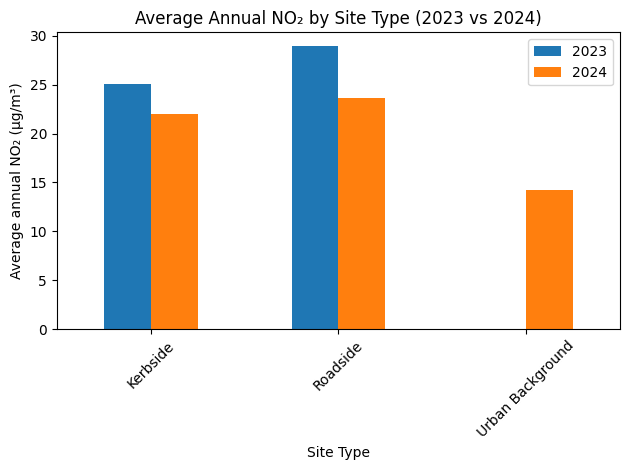

In [31]:
avg_annual_no2_by_site_2023 = df_2023.groupby('Site Type')['Annual mean – annualised and bias adjusted '].mean()

avg_annual_no2_by_site_comparison = pd.concat([avg_annual_no2_by_site_2023, avg_annual_no2_by_site_2024], axis=1)
avg_annual_no2_by_site_comparison.columns = ['2023', '2024']

display(avg_annual_no2_by_site_comparison)

avg_annual_no2_by_site_comparison.plot(kind='bar')

plt.xlabel('Site Type')
plt.ylabel('Average annual NO₂ (µg/m³)')
plt.title('Average Annual NO₂ by Site Type (2023 vs 2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This section compares the average annual NO₂ concentrations by site type between 2023 and 2024, visualizing the differences with a bar plot.

##4.7 2023 Data Cleaning

In [32]:
from numpy import average

cleaned_monthly_data_2023 = df_2023[['Jan ', 'Feb', 'Mar ', 'Apr ', 'May ', 'June ', 'Jul ', 'Aug ', 'Sept ', 'Oct ', 'Nov ', 'Dec ']].replace('-', pd.NA)

cleaned_monthly_data_2023 = cleaned_monthly_data_2023.apply(pd.to_numeric)

avg_monthly_no2_2023 = cleaned_monthly_data_2023.mean()

avg_monthly_no2_2023.index = avg_monthly_no2_2023.index.str.strip()

avg_monthly_no2_2023 = avg_monthly_no2_2023.rename(index = {'June': 'Jun' })

This cell cleans the 2023 monthly data by replacing missing values, converting to numeric types, and standardizing month names for consistency.

##4.8 Comparison  between 2023 and 2024 (Seasonal)

,2023,2024
Jan,41.296552,31.890476
Feb,41.703571,32.439881
Mar,31.722222,30.384337
Apr,33.583871,24.457059
May,26.540000,27.377059
Jun,27.248276,24.246341
Jul,25.760714,25.257865
Aug,28.013793,25.027586
Sept,37.800000,27.182386
Oct,38.266667,30.668675


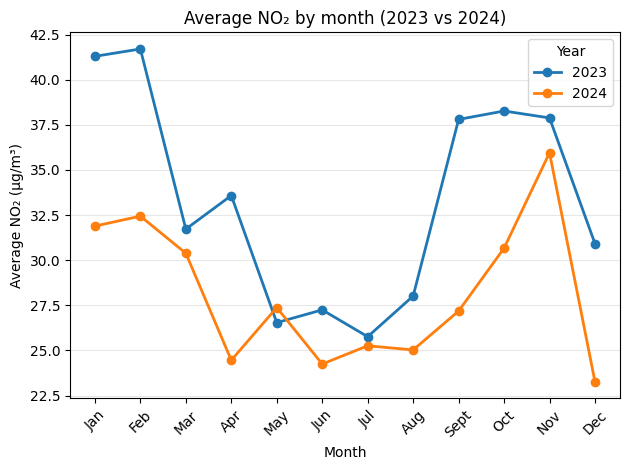

In [33]:
avg_monthly_no2_comparison = pd.concat([avg_monthly_no2_2023, avg_monthly_no2_2024], axis = 1)

avg_monthly_no2_comparison.columns = ['2023', '2024']

display(avg_monthly_no2_comparison)

avg_monthly_no2_comparison.plot(marker = 'o', linewidth = 2)
plt.xlabel('Month')
plt.ylabel('Average NO₂ (µg/m³)')
plt.xticks(range(12), avg_monthly_no2_comparison.index, rotation = 45)
plt.title('Average NO₂ by month (2023 vs 2024)')
plt.grid(axis = 'y', alpha =0.3)
plt.legend(title = 'Year')
plt.tight_layout()
plt.show()

This section compares the average monthly NO₂ trends between 2023 and 2024 to highlight seasonal differences and year-over-year changes.

##4.9 Comparison of Site Types between years

In [34]:
annual_avg_no2_site_difference = avg_annual_no2_by_site_comparison['2023'] - avg_annual_no2_by_site_comparison['2024']
annual_avg_no2_site_difference.name = 'Difference'
display(annual_avg_no2_site_difference)

#Spread inspection across 2024 (Where there is more data)
annual_avg_no2_std_by_site = df_2024.groupby('Site Type')['Annual mean - annualised and bias adjusted'].std()
annual_avg_no2_std_by_site.name = 'Standard Deviation'
display(annual_avg_no2_std_by_site)

,Difference
Site Type,
Kerbside,3.086874
Roadside,5.282500
Urban Background,NaN


,Standard Deviation
Site Type,
Kerbside,4.784241
Roadside,8.036141
Urban Background,2.189709


This cell calculates the annual average NO₂ difference between 2023 and 2024 for each site type, and also inspects the standard deviation of annual NO₂ for 2024 to understand the spread.

### 5. Conclusions


- Roadside and Kerbside monitoring sites recorded higher average NO₂ concentrations than Urban Background sites during 2024, as expected due to their proximity to traffic.

- A clear seasonal trend was observed. Average NO₂ concentrations were lowest during the summer months and increased towards autumn, reaching their highest levels in November.

- Roadside sites generally recorded the highest monthly concentrations throughout the year, with Kerbside exceeding Roadside only during May.

- The largest difference between Roadside and Urban Background concentrations occurred in September.

- Kerbside sites showed the greatest month-to-month variation throughout 2024.

- Comparing both years, average NO₂ concentrations were lower in 2024 than in 2023, suggesting an overall improvement in air quality.

- Similar seasonal behaviour was observed in both years, although May was the only month in which pollution did not decrease in 2024 compared with 2023.

- Roadside sites exhibited the largest reduction in annual average NO₂ concentrations between 2023 and 2024.



### 6. Limitations

- The number of monitoring sites differed substantially between 2023 and 2024, making direct comparisons between years less reliable.

- The distribution of monitoring site types was also imbalanced within each dataset. For example, Kerbside sites greatly outnumbered Roadside sites, meaning some averages may be more representative than others.

- No Urban Background monitoring sites were available in the 2023 dataset, preventing direct comparisons for this site type between years.

- The analysis only includes two years of observations. Using a longer time period would provide a more reliable assessment of long-term trends.

- Although lower NO₂ concentrations were consistently observed during the summer months, this project cannot determine whether weather or seasonal conditions caused this pattern. The analysis identifies correlations rather than proving causation.

### 7. Future Work

- Expand the analysis by including data from additional years to provide a more reliable assessment of long-term air quality trends.

- Incorporate meteorological data (e.g. temperature, rainfall and wind speed) to investigate possible environmental factors influencing NO₂ concentrations.

- Develop a machine learning model capable of forecasting future NO₂ concentrations at monitoring sites. Such a model could help environmental agencies identify high-risk locations and support pollution management strategies.

- Investigate possible causal relationships by combining pollution measurements with external datasets such as weather conditions and traffic volumes, allowing a more comprehensive understanding of the observed seasonal trends.

- Create interactive maps using the monitoring site coordinates to visualise the spatial distribution of NO₂ concentrations across Tower Hamlets.